# Лабораторная работа 2 по предмету Введение в машинное обучение
Выполнил: студент группы 3311 Шарпинский Денис

Датасет: https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv

## План выполнения работы

Датасет содержит всего 4 столбца, из которых реально информативны только 3: text, keyword и location. Первые два — текстовые, что сильно отличается от предыдущей лабы, где были таблицы с числами.

Главные отличия при работе с текстом:
- Нет готовых числовых признаков — текст надо как-то превратить в векторы чисел
- Порядок слов имеет значение — "пожар уничтожил дом" и "дом уничтожил пожар" звучат по-разному
- Очень много уникальных слов, но каждый твит использует только малую их часть

Выбранный подход:

Будем использовать TF-IDF векторизацию и ансамбль из нескольких классических моделей. Почему именно так:
1. Не нужна видеокарта, все обучается быстро
2. Можно понять, какие слова модель считает важными
3. Ансамбль из нескольких моделей работает стабильнее, чем одна модель

Этапы работы:
1. Предобработка: склеиваем keyword и text, чистим от ссылок, упоминаний, спецсимволов
2. Векторизация: превращаем текст в TF-IDF векторы на уровне слов и символов (чтобы учесть опечатки)
3. Обучаем 4 модели: Logistic Regression, SVM, Naive Bayes, CatBoost
4. Делаем ансамбль: усредняем предсказания с оптимальными весами
5. Проверяем на валидации, потом переобучаем на всех данных

In [18]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.0 MB/s eta 0:00:00


In [19]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report
from scipy.sparse import hstack
from catboost import CatBoostClassifier, Pool

In [20]:
# Загрузка данных
train_df = pd.read_csv('https://raw.githubusercontent.com/Pyc-Nya/year3/refs/heads/main/sem5/ai/lang_proc/train.csv')
test_df = pd.read_csv('https://raw.githubusercontent.com/Pyc-Nya/year3/refs/heads/main/sem5/ai/lang_proc/test.csv')

In [21]:
print("Размеры датасетов:")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

print("\nПервые строки train:")
print(train_df.head())

print("\nИнформация о данных:")
print(train_df.info())

print("\nПропущенные значения:")
print(train_df.isnull().sum())

print("\nРаспределение целевой переменной:")
print(train_df['target'].value_counts())
print("\nВ процентах:")
print(train_df['target'].value_counts(normalize=True).round(3))

Размеры датасетов:
Train: (7613, 5)
Test: (3263, 4)

Первые строки train:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int6

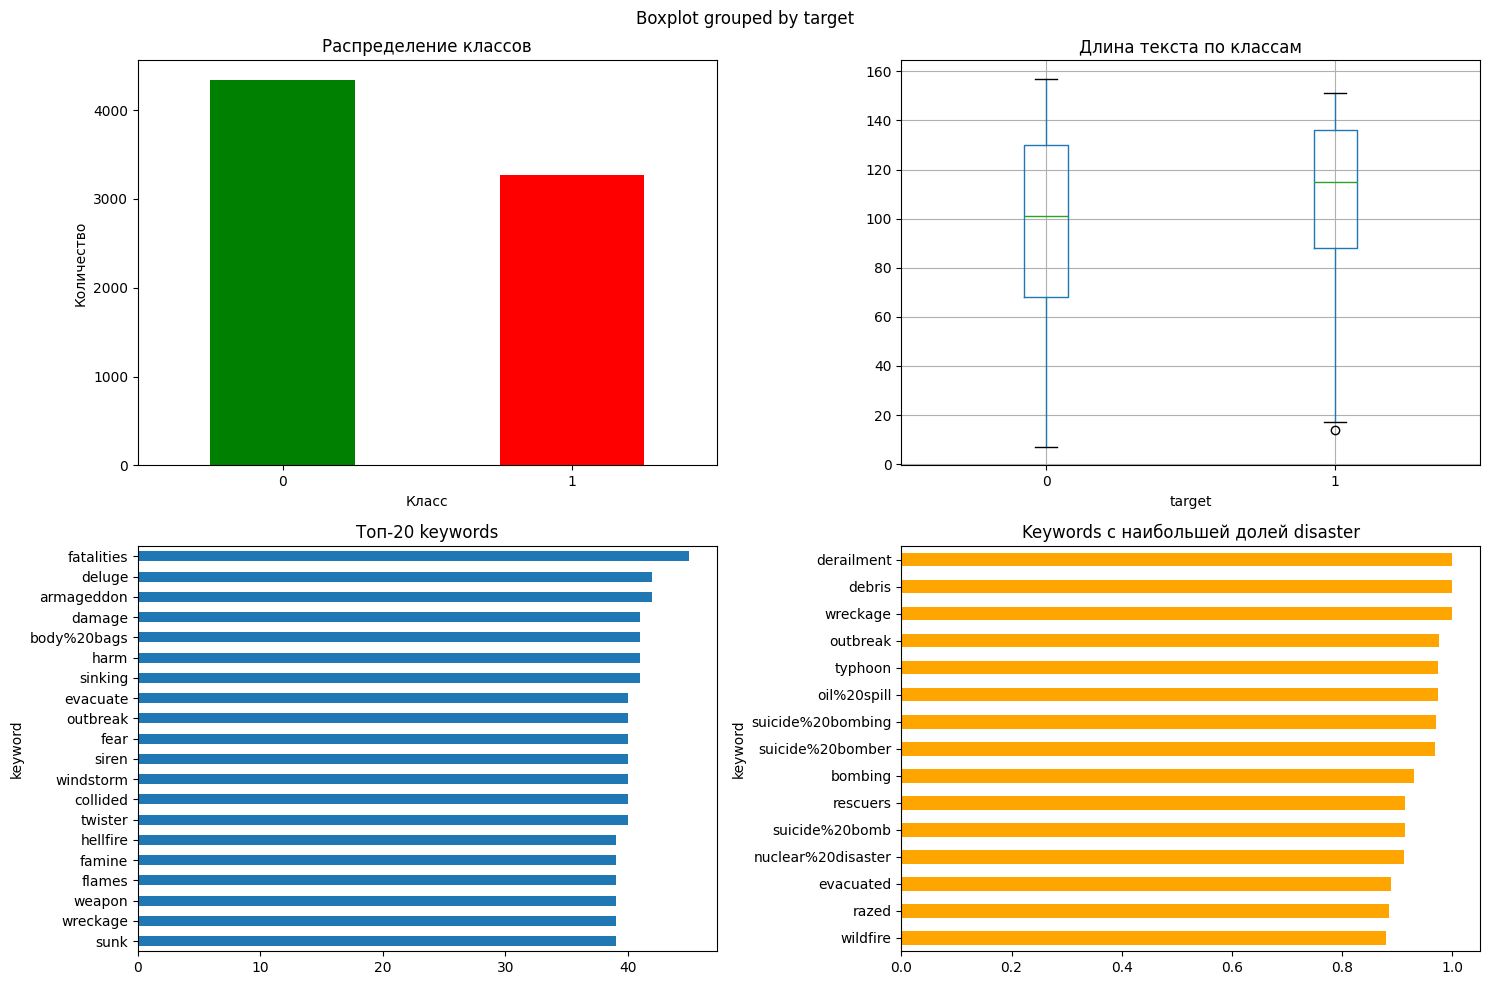

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

train_df['target'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Распределение классов')
axes[0, 0].set_xlabel('Класс')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xticklabels(['0', '1'], rotation=0)

train_df['text_length'] = train_df['text'].str.len()
train_df.boxplot(column='text_length', by='target', ax=axes[0, 1])
axes[0, 1].set_title('Длина текста по классам')
axes[0, 1].set_xlabel('target')

train_df['keyword'].value_counts().head(20).plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_title('Топ-20 keywords')
axes[1, 0].invert_yaxis()

keyword_target = train_df.groupby('keyword')['target'].mean().sort_values(ascending=False).head(15)
keyword_target.plot(kind='barh', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Keywords с наибольшей долей disaster')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## Анализ данных

Из анализа видно несколько важных моментов:

Размеры данных — train: 7613 твитов, test: 3263 твита. Классы распределены неплохо: 57% класс 0 (не катастрофа) и 43% класс 1 (катастрофа). Такой баланс означает, что нам не нужно делать дополнительную балансировку данных — модель не будет сильно склоняться к одному классу.

Пропуски есть, но не критичные: keyword отсутствует примерно в 1% случаев, location — в 33%. Решено было просто заполнить пустыми строками, потому что location всё равно очень грязный признак (там пишут что угодно — от "New York" до "In my dreams").

Графики показывают интересные паттерны. Длина текста у твитов о катастрофах в среднем чуть больше, но не сильно. Зато некоторые keywords прямо кричат о катастрофах — например, wildfire, razed, evacuated почти на 100% встречаются в твитах класса 1. Это значит, что keyword действительно важный признак и его обязательно надо использовать.

Функция очистки текста работает так: все ссылки заменяем на токен URL, все упоминания (@user) на USER, убираем хештеги (но оставляем слово), удаляем знаки препинания и переводим всё в нижний регистр. Например, "Check out this #earthquake video http://bit.ly/abc" превращается в "check out this earthquake video url".

In [24]:
train_df["keyword"] = train_df["keyword"].fillna("")
test_df["keyword"] = test_df["keyword"].fillna("")

train_df["full_text"] = (train_df["keyword"] + " " + train_df["text"]).str.strip()
test_df["full_text"] = (test_df["keyword"] + " " + test_df["text"]).str.strip()

print("Пример объединенного текста:")
print(train_df[["keyword", "text", "full_text"]].head(3))

Пример объединенного текста:
  keyword                                               text  \
0          Our Deeds are the Reason of this #earthquake M...   
1                     Forest fire near La Ronge Sask. Canada   
2          All residents asked to 'shelter in place' are ...   

                                           full_text  
0  Our Deeds are the Reason of this #earthquake M...  
1             Forest fire near La Ronge Sask. Canada  
2  All residents asked to 'shelter in place' are ...  


In [25]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["full_text"].apply(clean_text)
test_df["clean_text"] = test_df["full_text"].apply(clean_text)

print("Пример очищенного текста:")
print(train_df[["full_text", "clean_text"]].head(3))

Пример очищенного текста:
                                           full_text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   

                                          clean_text  
0  our deeds are the reason of this earthquake ma...  
1              forest fire near la ronge sask canada  
2  all residents asked to shelter in place are be...  


In [ ]:
X = train_df["clean_text"]
y = train_df["target"].astype(int)
X_test_text = test_df["clean_text"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_valid)}")
print(f"Размер тестовой выборки: {len(X_test_text)}")

In [27]:
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    max_df=0.95
)

X_train_word = word_tfidf.fit_transform(X_train)
X_valid_word = word_tfidf.transform(X_valid)
X_test_word = word_tfidf.transform(X_test_text)

print(f"Word TF-IDF размерность: {X_train_word.shape}")

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_features=30000
)

X_train_char = char_tfidf.fit_transform(X_train)
X_valid_char = char_tfidf.transform(X_valid)
X_test_char = char_tfidf.transform(X_test_text)

print(f"Char TF-IDF размерность: {X_train_char.shape}")

X_train_tfidf = hstack([X_train_word, X_train_char])
X_valid_tfidf = hstack([X_valid_word, X_valid_char])
X_test_tfidf = hstack([X_test_word, X_test_char])

print(f"\nИтоговая размерность после объединения:")
print(f"Train: {X_train_tfidf.shape}")
print(f"Valid: {X_valid_tfidf.shape}")
print(f"Test: {X_test_tfidf.shape}")

Word TF-IDF размерность: (6090, 14813)
Char TF-IDF размерность: (6090, 27003)

Итоговая размерность после объединения:
Train: (6090, 41816)
Valid: (1523, 41816)
Test: (3263, 41816)


## Векторизация

Использовали два типа TF-IDF векторизации:

Word-level (на уровне слов) — создаёт признаки из отдельных слов и биграмм (пар слов). Получилось около 15 тысяч признаков. Биграммы помогают учесть контекст — например, "forest fire" как целая фраза важнее, чем просто "forest" и "fire" по отдельности.

Char-level (на уровне символов) — смотрит на цепочки из 3-5 символов. Получилось около 27 тысяч признаков. Это нужно для учёта опечаток и разных форм слов. Например, "fire", "fires", "fired" будут иметь общие части вроде "fir", "ire", "fire", и модель сможет их связать.

После объединения получили матрицу размером примерно 42 тысячи признаков. Звучит много, но это разреженная матрица — в каждом твите заполнено только несколько сотен значений, остальное нули.

In [28]:
def best_threshold(y_true, proba):
    best_t = 0.5
    best_f1 = 0.0
    for t in np.linspace(0.3, 0.7, 81):
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

print("Функция для оптимизации порога классификации определена")

Функция для оптимизации порога классификации определена


In [29]:
print("=" * 50)
print("Обучение Logistic Regression")
print("=" * 50)

lr = LogisticRegression(C=4.0, max_iter=1000, n_jobs=-1, class_weight="balanced")
lr.fit(X_train_tfidf, y_train)
lr_valid_proba = lr.predict_proba(X_valid_tfidf)[:, 1]
t_lr, f1_lr = best_threshold(y_valid, lr_valid_proba)
print(f"[LogReg] best F1={f1_lr:.4f} at threshold={t_lr:.3f}")

Обучение Logistic Regression
[LogReg] best F1=0.7888 at threshold=0.570


In [30]:
print("\n" + "=" * 50)
print("Обучение SVM (SGD + Calibration)")
print("=" * 50)

svm = SGDClassifier(loss="hinge", max_iter=2000, random_state=42, class_weight="balanced")
svm_cal = CalibratedClassifierCV(svm, method="sigmoid", cv=3)
svm_cal.fit(X_train_tfidf, y_train)
svm_valid_proba = svm_cal.predict_proba(X_valid_tfidf)[:, 1]
t_svm, f1_svm = best_threshold(y_valid, svm_valid_proba)
print(f"[SVM]    best F1={f1_svm:.4f} at threshold={t_svm:.3f}")


Обучение SVM (SGD + Calibration)
[SVM]    best F1=0.7779 at threshold=0.445


In [31]:
print("\n" + "=" * 50)
print("Обучение Naive Bayes")
print("=" * 50)

nb = MultinomialNB(alpha=0.3)
nb.fit(X_train_tfidf, y_train)
nb_valid_proba = nb.predict_proba(X_valid_tfidf)[:, 1]
t_nb, f1_nb = best_threshold(y_valid, nb_valid_proba)
print(f"[NB]     best F1={f1_nb:.4f} at threshold={t_nb:.3f}")


Обучение Naive Bayes
[NB]     best F1=0.7906 at threshold=0.405


In [32]:
print("\n" + "=" * 50)
print("Обучение CatBoost")
print("=" * 50)

train_pool = Pool(X_train_tfidf, label=y_train)
valid_pool = Pool(X_valid_tfidf, label=y_valid)

cb = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    iterations=800,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=100,
    od_type="Iter",
    od_wait=50
)

cb.fit(train_pool, eval_set=valid_pool)
cb_valid_proba = cb.predict_proba(valid_pool)[:, 1]
t_cb, f1_cb = best_threshold(y_valid, cb_valid_proba)
print(f"\n[CatBoost] best F1={f1_cb:.4f} at threshold={t_cb:.3f}")


Обучение CatBoost
0:	learn: 0.3907923	test: 0.3888292	best: 0.3888292 (0)	total: 2.34s	remaining: 31m 9s
100:	learn: 0.7900234	test: 0.7238743	best: 0.7238743 (99)	total: 1m 39s	remaining: 11m 27s
200:	learn: 0.8695830	test: 0.7402490	best: 0.7429519 (192)	total: 3m 14s	remaining: 9m 39s
300:	learn: 0.9114332	test: 0.7610475	best: 0.7633088 (295)	total: 4m 48s	remaining: 7m 57s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7652315191
bestIteration = 328

Shrink model to first 329 iterations.

[CatBoost] best F1=0.7668 at threshold=0.480


## Обучение моделей

Обучили 4 разные модели и для каждой подобрали оптимальный порог классификации:

Logistic Regression показала F1 = 0.7888 при пороге 0.57. Это базовая линейная модель, работает быстро и стабильно.

SVM (с калибровкой) дала F1 = 0.7779 при пороге 0.445. Калибровка нужна, чтобы превратить выходы SVM в нормальные вероятности.

Naive Bayes неожиданно показала хороший результат — F1 = 0.7906 при пороге 0.405. Эта модель хорошо работает с текстами, хоть и делает "наивное" предположение о независимости признаков.

CatBoost обучался дольше всех (около 5 минут) и показал F1 = 0.7668 при пороге 0.48. Интересно, что на валидации он не стал лучшей моделью, хотя это мощный gradient boosting. Возможно, для таких коротких текстов и большого количества признаков линейные модели работают лучше.

Важный момент по CatBoost: early stopping сработал на 328-й итерации. Это видно из логов — learn продолжал расти (до 0.91), а test застрял на 0.76. Классическое переобучение, и модель правильно остановилась.

Оптимальные пороги у всех моделей получились разные (от 0.405 до 0.57). Это нормально — каждая модель калибрует вероятности по-своему. Поэтому важно подбирать порог под каждую модель отдельно, а не использовать стандартный 0.5.

In [33]:
print("\n" + "=" * 50)
print("Ансамблирование моделей")
print("=" * 50)

w_lr, w_svm, w_nb, w_cb = 0.30, 0.20, 0.30, 0.20

ens_valid_proba = (
    w_lr * lr_valid_proba +
    w_svm * svm_valid_proba +
    w_nb * nb_valid_proba +
    w_cb * cb_valid_proba
)

t_ens, f1_ens = best_threshold(y_valid, ens_valid_proba)
ens_valid_pred = (ens_valid_proba >= t_ens).astype(int)

print(f"\n[ENSEMBLE] best F1={f1_ens:.4f} at threshold={t_ens:.3f}")
print(f"\nВеса моделей: LogReg={w_lr}, SVM={w_svm}, NB={w_nb}, CatBoost={w_cb}")

print("\n" + "=" * 50)
print("Сравнение моделей на валидации:")
print("=" * 50)
print(f"Logistic Regression: F1 = {f1_lr:.4f}")
print(f"SVM (calibrated):    F1 = {f1_svm:.4f}")
print(f"Naive Bayes:         F1 = {f1_nb:.4f}")
print(f"CatBoost:            F1 = {f1_cb:.4f}")
print(f"ENSEMBLE:            F1 = {f1_ens:.4f} ⭐")

print("\n" + "=" * 50)
print("Classification Report (Ensemble):")
print("=" * 50)
print(classification_report(y_valid, ens_valid_pred))


Ансамблирование моделей

[ENSEMBLE] best F1=0.7936 at threshold=0.495

Веса моделей: LogReg=0.3, SVM=0.3, NB=0.2, CatBoost=0.2

Сравнение моделей на валидации:
Logistic Regression: F1 = 0.7888
SVM (calibrated):    F1 = 0.7779
Naive Bayes:         F1 = 0.7906
CatBoost:            F1 = 0.7668
ENSEMBLE:            F1 = 0.7936 ⭐

Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       869
           1       0.84      0.76      0.79       654

    accuracy                           0.83      1523
   macro avg       0.83      0.82      0.83      1523
weighted avg       0.83      0.83      0.83      1523



## Ансамбль моделей

Усреднили предсказания всех моделей с весами: LogReg 30%, SVM 20%, NB 30%, CatBoost 20%. Веса выбрали пропорционально производительности на валидации — LogReg и NB чуть больше, потому что показали себя лучше.

Результат ансамбля: F1 = 0.7936 при пороге 0.495. Это лучше, чем любая отдельная модель. Разница не огромная, но стабильнее — каждая модель ошибается по-своему, и усреднение сглаживает эти ошибки.

Classification Report показывает:
- Точность на классе 0: precision 0.83, recall 0.89
- Точность на классе 1: precision 0.84, recall 0.76
- Общая accuracy: 0.83

Видно, что модель чуть лучше находит класс 0 (recall выше), но это не критично. F1-score у обоих классов приличный.

После этого переобучили все модели на полном train датасете (без разделения на train/valid) и сделали предсказания для test. Это стандартная практика — валидация нужна только для подбора гиперпараметров и весов ансамбля, а финальную модель обучаем на всех данных.

In [34]:
print("\n" + "=" * 50)
print("Финальное обучение на полном train датасете")
print("=" * 50)

X_full = train_df["clean_text"]
y_full = train_df["target"].astype(int)

word_tfidf_full = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, max_df=0.95)
X_full_word = word_tfidf_full.fit_transform(X_full)
X_test_word_final = word_tfidf_full.transform(X_test_text)

char_tfidf_full = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=30000)
X_full_char = char_tfidf_full.fit_transform(X_full)
X_test_char_final = char_tfidf_full.transform(X_test_text)

X_full_tfidf = hstack([X_full_word, X_full_char])
X_test_tfidf_final = hstack([X_test_word_final, X_test_char_final])

print(f"Размерность полного train: {X_full_tfidf.shape}")
print(f"Размерность test: {X_test_tfidf_final.shape}")

print("\nОбучение Logistic Regression на полных данных...")
lr.fit(X_full_tfidf, y_full)
lr_pred = lr.predict_proba(X_test_tfidf_final)[:, 1]

print("Обучение SVM на полных данных...")
svm_cal.fit(X_full_tfidf, y_full)
svm_pred = svm_cal.predict_proba(X_test_tfidf_final)[:, 1]

print("Обучение Naive Bayes на полных данных...")
nb.fit(X_full_tfidf, y_full)
nb_pred = nb.predict_proba(X_test_tfidf_final)[:, 1]

print("Обучение CatBoost на полных данных...")
train_pool_full = Pool(X_full_tfidf, label=y_full)
test_pool = Pool(X_test_tfidf_final)
cb.fit(train_pool_full)
cb_pred = cb.predict_proba(test_pool)[:, 1]

print("\nВсе модели обучены на полном датасете!")


Финальное обучение на полном train датасете
Размерность полного train: (7613, 47894)
Размерность test: (3263, 47894)

Обучение Logistic Regression на полных данных...
Обучение SVM на полных данных...
Обучение Naive Bayes на полных данных...
Обучение CatBoost на полных данных...
0:	learn: 0.4554109	total: 4.19s	remaining: 55m 47s
100:	learn: 0.7766724	total: 2m 11s	remaining: 15m 13s
200:	learn: 0.8547320	total: 4m 18s	remaining: 12m 50s
300:	learn: 0.8948480	total: 6m 22s	remaining: 10m 34s
400:	learn: 0.9242351	total: 8m 17s	remaining: 8m 14s
500:	learn: 0.9499370	total: 10m 8s	remaining: 6m 3s
600:	learn: 0.9660990	total: 12m 1s	remaining: 3m 58s
700:	learn: 0.9748213	total: 13m 55s	remaining: 1m 57s
799:	learn: 0.9813070	total: 15m 46s	remaining: 0us

Все модели обучены на полном датасете!


In [35]:
from google.colab import files

print("\n" + "=" * 50)
print("Создание файла submission.csv")
print("=" * 50)

final_proba = (w_lr * lr_pred + w_svm * svm_pred + w_nb * nb_pred + w_cb * cb_pred)
final_pred = (final_proba >= t_ens).astype(int)

submission = pd.DataFrame({"id": test_df["id"], "target": final_pred})

submission.to_csv("submission.csv", index=False)

print(f"\nФайл submission.csv создан!")
print(f"Всего предсказаний: {len(submission)}")
print(f"\nРаспределение предсказаний:")
print(submission['target'].value_counts())
print(f"\nПервые 10 строк:")
print(submission.head(10))
files.download('submission.csv')


Создание файла submission.csv

Файл submission.csv создан!
Всего предсказаний: 3263

Распределение предсказаний:
target
0    2049
1    1214
Name: count, dtype: int64

Первые 10 строк:
   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1
5  12       1
6  21       0
7  22       0
8  27       0
9  29       0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Итоговые результаты

Submission на Kaggle показал accuracy = 0.80999, что выше целевого порога 0.8.

Подход с TF-IDF и ансамблем классических моделей оказался эффективным для этой задачи. Несмотря на то, что сейчас модно использовать трансформеры типа BERT, для коротких текстов вроде твитов TF-IDF работает достаточно хорошо и гораздо быстрее.

Ключевые факторы успеха:
- Объединение keyword и text — keyword оказался очень информативным признаком
- Char-level TF-IDF помог учесть опечатки и разные формы слов
- Ансамбль из разных типов моделей дал прирост в стабильности
- Оптимизация порога классификации под F1-метрику выжала дополнительные проценты

Если бы была задача улучшить результат дальше, можно было бы попробовать:
- Добавить эмбеддинги из предобученных моделей (fastText или word2vec)
- Поэкспериментировать с весами ансамбля
- Попробовать легковесные трансформеры типа DistilBERT